# Notebook 12: Calibration & Reliability

This notebook evaluates whether the probability estimates from Notebooks 08, 09, and 10 are trustworthy.

**Required reliability measures:** Log Loss, multiclass Brier Score, Expected Calibration Error (ECE), and reliability diagrams.

The notebook evaluates the existing 2025 test predictions. It does **not** fit a calibrator on the 2025 test set, avoiding test-set leakage.

Research design: temporal evaluation, stock-specific, pooled, and leave-one-stock-out testing, followed by calibration/reliability analysis.

## Why calibration?

Accuracy answers **"Was the class correct?"**

Calibration asks **"Can I trust the probability attached to that prediction?"**

For example, predictions with approximately 0.70 confidence should be correct roughly 70% of the time if they are well calibrated.

We therefore evaluate probability quality separately from classification performance. Log Loss and Brier Score are proper scoring rules; Brier Score also reflects discrimination/resolution, so it should not be interpreted as a pure calibration measure.

In [1]:
# ==========================================================
# Imports and configuration
# ==========================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = {0: "Down", 1: "Neutral", 2: "Up"}

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.5f}".format)

## Locate prediction files

Notebook 08 provides the stock-specific probability predictions in:

`baseline_predictions.csv`

The separate `baseline_model_performance.csv` file is **not used here**, because calibration requires the actual labels and class probabilities.

Notebook 09 and Notebook 10 provide their prediction CSVs from the pooled and leave-one-stock-out experiments.

In [2]:
# ==========================================================
# Prediction-file paths
# ==========================================================

# Notebook 08: stock-specific / baseline predictions
STOCK_SPECIFIC_PATH = (
    "/kaggle/input/notebooks/phyothaw/"
    "08-baseline-modelling-ipynb/baseline_predictions.csv"
)

# Notebook 09 and 10 outputs
POOLED_FILENAME = "/kaggle/input/notebooks/phyothaw/09-pooled-global-model-ipynb/pooled_model_predictions.csv"
LOSO_FILENAME = "/kaggle/input/notebooks/phyothaw/10-cross-stock-generalisation-ipynb/loso_model_predictions.csv"

POOLED_PATH = POOLED_FILENAME
LOSO_PATH = LOSO_FILENAME

print("Stock-specific:", STOCK_SPECIFIC_PATH)
print("Pooled:", POOLED_PATH)
print("LOSO:", LOSO_PATH)

Stock-specific: /kaggle/input/notebooks/phyothaw/08-baseline-modelling-ipynb/baseline_predictions.csv
Pooled: /kaggle/input/notebooks/phyothaw/09-pooled-global-model-ipynb/pooled_model_predictions.csv
LOSO: /kaggle/input/notebooks/phyothaw/10-cross-stock-generalisation-ipynb/loso_model_predictions.csv


## Standardise the prediction tables

The required fields are:

- `actual`
- `prob_down`
- `prob_neutral`
- `prob_up`

The notebook also preserves `model`, `stock`, and `date` where available.

In [3]:
# ==========================================================
# Standardise prediction files
# ==========================================================

def alias(df, names):
    for name in names:
        if name in df.columns:
            return name
    return None

def standardize(df, scenario):
    df = df.copy()

    actual = alias(df, ["actual", "y_true", "target", "true"])
    model = alias(df, ["model", "model_name"])
    stock = alias(df, ["ticker", "stock", "held_out_stock"])
    date = alias(df, ["date", "trading_date"])

    probs = {
        "prob_down": alias(df, ["prob_down", "prob_0", "p_down", "class_0_prob"]),
        "prob_neutral": alias(df, ["prob_neutral", "prob_1", "p_neutral", "class_1_prob"]),
        "prob_up": alias(df, ["prob_up", "prob_2", "p_up", "class_2_prob"]),
    }

    if actual is None or any(v is None for v in probs.values()):
        raise ValueError(
            f"{scenario}: required actual/probability columns were not found. "
            f"Columns are: {list(df.columns)}"
        )

    out = pd.DataFrame({
        "scenario": scenario,
        "stock": df[stock] if stock else "Unknown",
        "model": df[model] if model else "Unknown",
        "date": df[date] if date else pd.NaT,
        "actual": df[actual].astype(int),
        "prob_down": df[probs["prob_down"]].astype(float),
        "prob_neutral": df[probs["prob_neutral"]].astype(float),
        "prob_up": df[probs["prob_up"]].astype(float),
    })

    return out

frames = []

if STOCK_SPECIFIC_PATH:
    frames.append(
        standardize(
            pd.read_csv(STOCK_SPECIFIC_PATH),
            "Stock-specific"
        )
    )

if POOLED_PATH:
    frames.append(
        standardize(
            pd.read_csv(POOLED_PATH),
            "Pooled"
        )
    )

if LOSO_PATH:
    frames.append(
        standardize(
            pd.read_csv(LOSO_PATH),
            "Leave-one-stock-out"
        )
    )

predictions_df = pd.concat(frames, ignore_index=True)

print("Total prediction rows:", len(predictions_df))
display(predictions_df.head())

Total prediction rows: 15820


,scenario,stock,model,date,actual,prob_down,prob_neutral,prob_up
0,Stock-specific,BRK-B,Dummy,2025-01-02,0,0.00000,1.00000,0.00000
1,Stock-specific,BRK-B,Dummy,2025-01-03,0,0.00000,1.00000,0.00000
2,Stock-specific,BRK-B,Dummy,2025-01-06,1,0.00000,1.00000,0.00000
3,Stock-specific,BRK-B,Dummy,2025-01-07,1,0.00000,1.00000,0.00000
4,Stock-specific,BRK-B,Dummy,2025-01-08,2,0.00000,1.00000,0.00000


In [4]:
# ==========================================================
# Probability validation
# ==========================================================

PROB_COLS = ["prob_down", "prob_neutral", "prob_up"]

prob_sum = predictions_df[PROB_COLS].sum(axis=1)

print("Maximum probability-sum error:",
      np.abs(prob_sum - 1).max())

print("Minimum probability:",
      predictions_df[PROB_COLS].min().min())

print("Maximum probability:",
      predictions_df[PROB_COLS].max().max())

assert (predictions_df[PROB_COLS] >= 0).all().all()
assert (predictions_df[PROB_COLS] <= 1).all().all()
assert np.abs(prob_sum - 1).max() < 1e-5

print("✓ Probability validation passed.")

Maximum probability-sum error: 8.940696738513054e-08
Minimum probability: 0.0
Maximum probability: 1.0
✓ Probability validation passed.


## Reliability metrics

### Log Loss
Evaluates the complete predicted probability distribution and strongly penalises confident incorrect predictions. Lower is better.

### Multiclass Brier Score
Mean squared difference between the one-hot true outcome and the predicted probability vector. Lower is better.

### Top-label ECE
Groups predictions by their maximum predicted probability and measures the weighted gap between confidence and observed accuracy. Lower is better.

### MCE
The largest calibration gap among the non-empty confidence bins.

In [5]:
# ==========================================================
# Reliability metric functions
# ==========================================================

def normalize_probabilities(probabilities):
    probabilities = np.asarray(probabilities, dtype=float)
    row_sums = probabilities.sum(axis=1, keepdims=True)

    if np.any(row_sums <= 0):
        raise ValueError("A probability row has a non-positive sum.")

    return probabilities / row_sums


def multiclass_brier(y_true, prob):
    y_true = np.asarray(y_true)
    prob = normalize_probabilities(prob)

    one_hot = np.zeros_like(prob)
    one_hot[np.arange(len(y_true)), y_true.astype(int)] = 1

    return np.mean(
        np.sum((one_hot - prob) ** 2, axis=1)
    )


def top_label_ece(y_true, prob, n_bins=10):
    y_true = np.asarray(y_true)
    prob = normalize_probabilities(prob)

    predicted = np.argmax(prob, axis=1)
    confidence = np.max(prob, axis=1)
    correct = (predicted == y_true).astype(int)

    edges = np.linspace(0, 1, n_bins + 1)
    rows = []

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]

        if i == n_bins - 1:
            mask = (confidence >= lo) & (confidence <= hi)
        else:
            mask = (confidence >= lo) & (confidence < hi)

        if mask.sum() == 0:
            continue

        rows.append({
            "bin_lower": lo,
            "bin_upper": hi,
            "count": int(mask.sum()),
            "confidence": confidence[mask].mean(),
            "accuracy": correct[mask].mean(),
        })

    bins = pd.DataFrame(rows)

    if bins.empty:
        return np.nan, np.nan, bins

    bins["gap"] = abs(
        bins["accuracy"] - bins["confidence"]
    )

    weights = bins["count"] / len(y_true)

    ece = np.sum(weights * bins["gap"])
    mce = bins["gap"].max()

    return ece, mce, bins

## Overall reliability results

In [6]:
# ==========================================================
# Overall reliability
# ==========================================================

rows = []

for (scenario, model), group in predictions_df.groupby(
    ["scenario", "model"]
):
    y = group["actual"].to_numpy()
    p = normalize_probabilities(group[PROB_COLS].to_numpy())

    ece, mce, _ = top_label_ece(y, p)

    rows.append({
        "scenario": scenario,
        "model": model,
        "n_predictions": len(group),
        "log_loss": log_loss(y, p, labels=CLASS_LABELS),
        "brier_score": multiclass_brier(y, p),
        "ece": ece,
        "mce": mce,
    })

reliability_results_df = pd.DataFrame(rows)

display(
    reliability_results_df.sort_values(
        ["scenario", "log_loss"]
    ).reset_index(drop=True)
)

,scenario,model,n_predictions,log_loss,brier_score,ece,mce
0,Leave-one-stock-out,Random Forest,1130,1.19543,0.73331,0.17912,0.48227
1,Leave-one-stock-out,Logistic Regression,1130,1.22945,0.71262,0.13620,0.63166
2,Leave-one-stock-out,XGBoost,1130,1.41382,0.85659,0.30102,0.65612
3,Leave-one-stock-out,Dummy Classifier,1130,22.51931,1.24956,0.62478,0.62478
4,Pooled,Logistic Regression,1130,1.07962,0.65607,0.05076,0.32629
5,Pooled,LSTM,1130,1.08022,0.65713,0.06682,0.11656
6,Pooled,Random Forest,1130,1.14210,0.69457,0.13126,0.29595
7,Pooled,XGBoost,1130,1.29558,0.79226,0.24829,0.68114
8,Pooled,Dummy Classifier,1130,22.51931,1.24956,0.62478,0.62478
9,Stock-specific,LSTM,1130,1.11813,0.67948,0.08967,0.26372


## Reliability by stock

In [7]:
# ==========================================================
# Reliability by stock
# ==========================================================

rows = []

for (scenario, model, stock), group in predictions_df.groupby(
    ["scenario", "model", "stock"]
):
    y = group["actual"].to_numpy()
    p = normalize_probabilities(group[PROB_COLS].to_numpy())

    ece, mce, _ = top_label_ece(y, p)

    rows.append({
        "scenario": scenario,
        "model": model,
        "stock": stock,
        "n_predictions": len(group),
        "log_loss": log_loss(y, p, labels=CLASS_LABELS),
        "brier_score": multiclass_brier(y, p),
        "ece": ece,
        "mce": mce,
    })

stock_reliability_df = pd.DataFrame(rows)

display(stock_reliability_df)

,scenario,model,stock,n_predictions,log_loss,brier_score,ece,mce
0,Leave-one-stock-out,Dummy Classifier,BRK-B,226,25.99609,1.44248,0.72124,0.72124
1,Leave-one-stock-out,Dummy Classifier,CVX,226,23.60381,1.30973,0.65487,0.65487
2,Leave-one-stock-out,Dummy Classifier,GE,226,18.50028,1.02655,0.51327,0.51327
3,Leave-one-stock-out,Dummy Classifier,MSFT,226,24.87969,1.38053,0.69027,0.69027
4,Leave-one-stock-out,Dummy Classifier,NVDA,226,19.61668,1.08850,0.54425,0.54425
...,...,...,...,...,...,...,...,...
65,Stock-specific,XGBoost,BRK-B,226,1.36038,0.78792,0.25549,0.47015
66,Stock-specific,XGBoost,CVX,226,1.87465,1.02951,0.45132,0.66226
67,Stock-specific,XGBoost,GE,226,1.60480,0.88527,0.31925,0.70095
68,Stock-specific,XGBoost,MSFT,226,1.83961,1.02615,0.47444,0.68844


## Reliability diagrams

A well-calibrated model should lie close to the diagonal:

**predicted confidence ≈ observed accuracy**

These are top-label reliability diagrams, appropriate for the multiclass prediction setting used here.

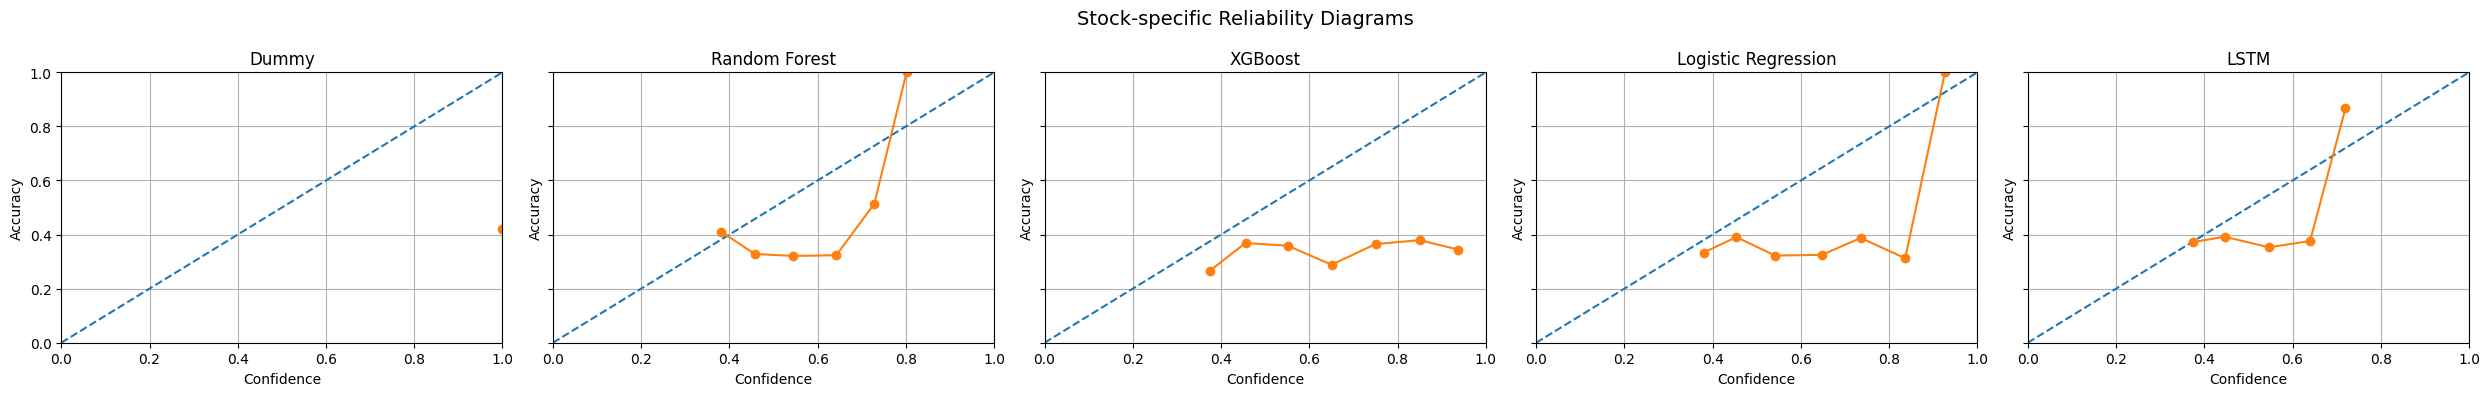

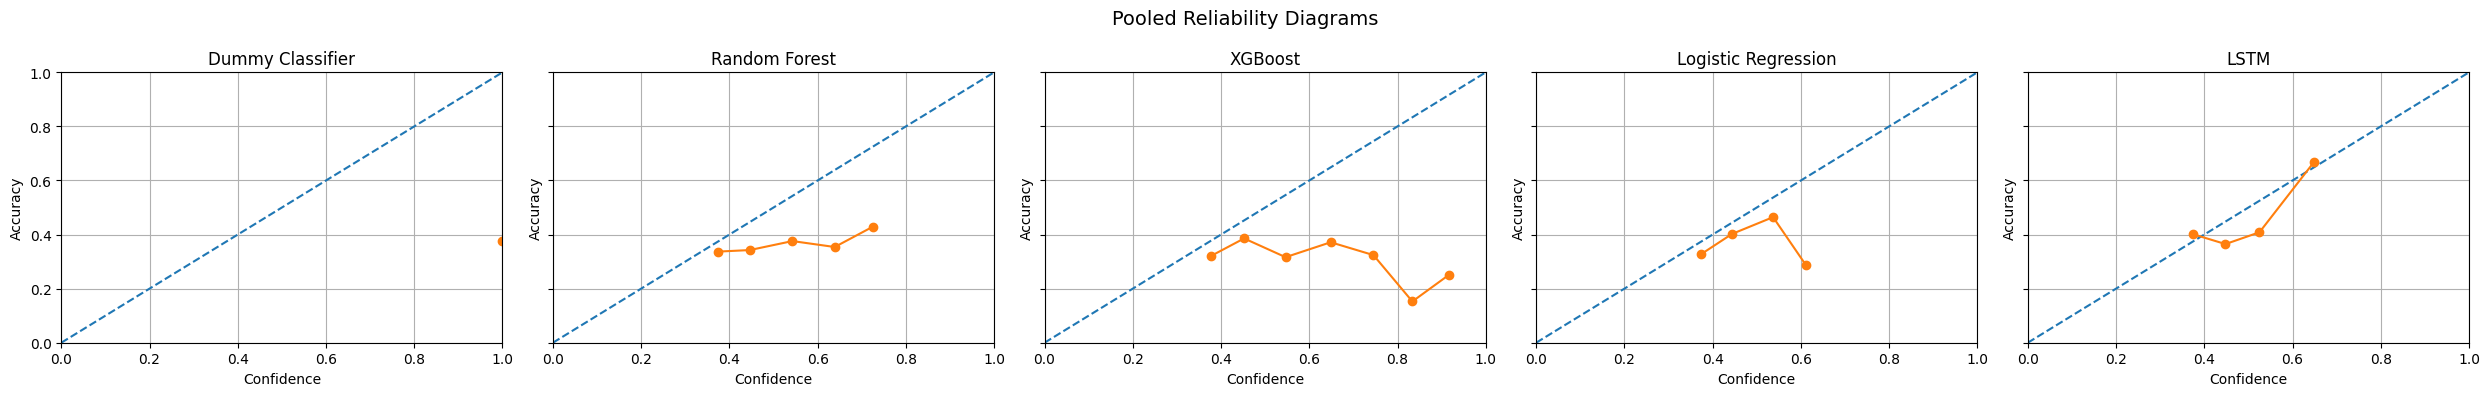

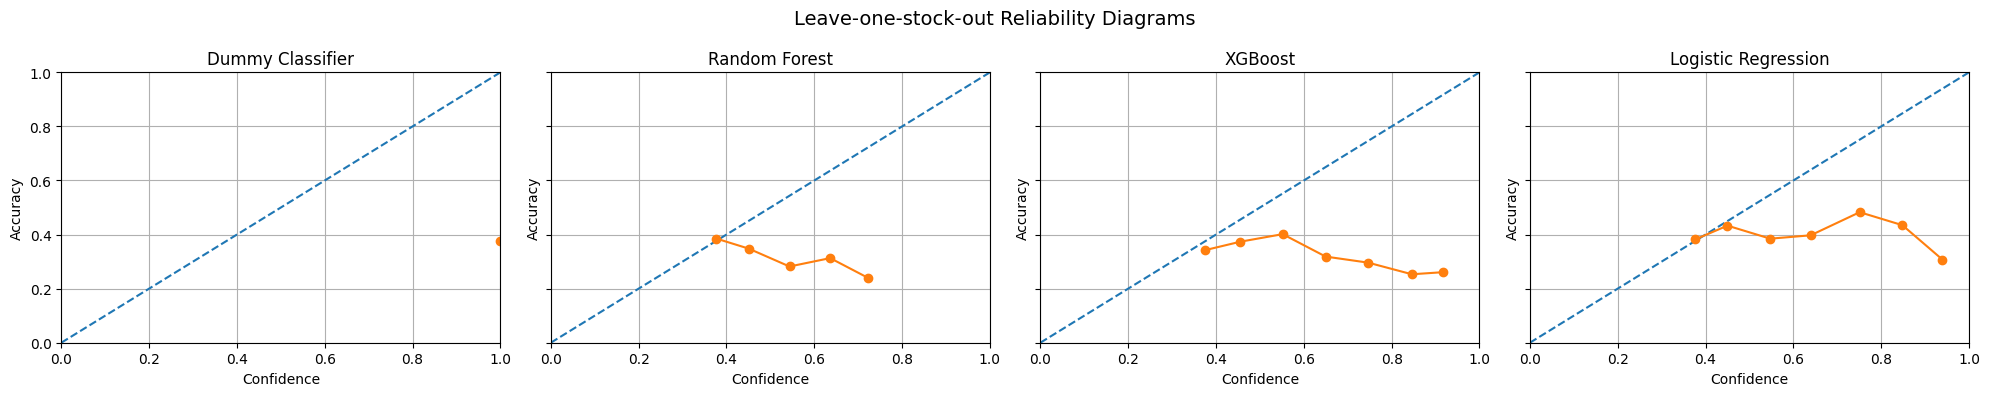

In [8]:
# ==========================================================
# Reliability Diagrams (Subplots)
# ==========================================================

scenarios = predictions_df["scenario"].unique()

for scenario in scenarios:

    models = predictions_df[predictions_df["scenario"] == scenario]["model"].unique()

    fig, axes = plt.subplots(1, len(models),figsize=(5 * len(models), 4),sharex=True,sharey=True)

    if len(models) == 1:
        axes = [axes]

    for ax, model in zip(axes, models):

        subset = predictions_df[
            (predictions_df["scenario"] == scenario) & (predictions_df["model"] == model)]

        y = subset["actual"].to_numpy()
        p = subset[PROB_COLS].to_numpy()

        _, _, bins = top_label_ece(y, p)

        ax.plot([0, 1], [0, 1], "--", label="Perfect")
        ax.plot(bins["confidence"], bins["accuracy"], marker="o", label=model)

        ax.set_title(model)
        ax.set_xlabel("Confidence")
        ax.set_ylabel("Accuracy")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True)

    fig.suptitle(f"{scenario} Reliability Diagrams", fontsize=14)
    plt.tight_layout()
    plt.show()

## Class-wise calibration diagnostic

Because this is a three-class problem, we also inspect the probability assigned to each class separately using a one-vs-rest view.

This is supplementary. The main calibration metric remains top-label ECE.

In [9]:
# ==========================================================
# Class-wise calibration function
# ==========================================================

def classwise_bins(y_true, prob, class_index, n_bins=10):
    y_binary = (
        np.asarray(y_true) == class_index
    ).astype(int)

    class_prob = np.asarray(prob)[:, class_index]

    edges = np.linspace(0, 1, n_bins + 1)
    rows = []

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]

        if i == n_bins - 1:
            mask = (class_prob >= lo) & (class_prob <= hi)
        else:
            mask = (class_prob >= lo) & (class_prob < hi)

        if mask.sum() == 0:
            continue

        rows.append({
            "probability": class_prob[mask].mean(),
            "observed_frequency": y_binary[mask].mean(),
            "count": int(mask.sum()),
        })

    return pd.DataFrame(rows)

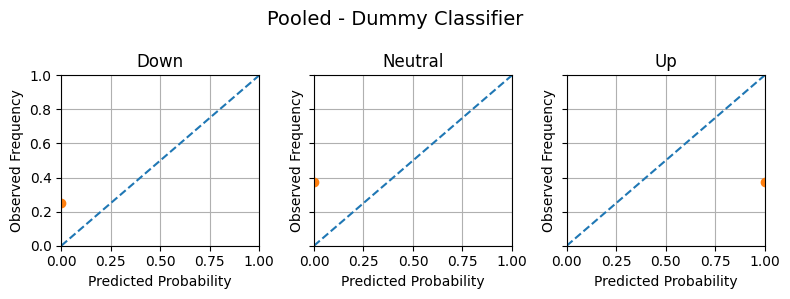

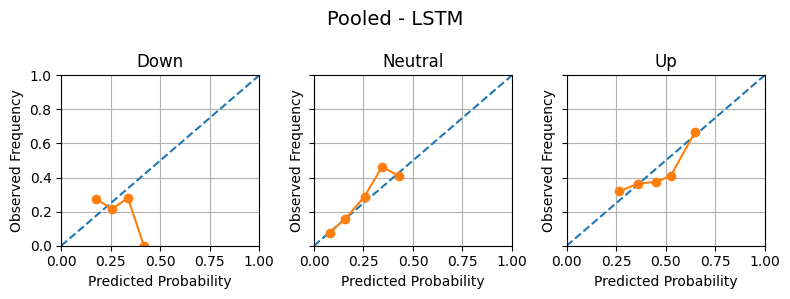

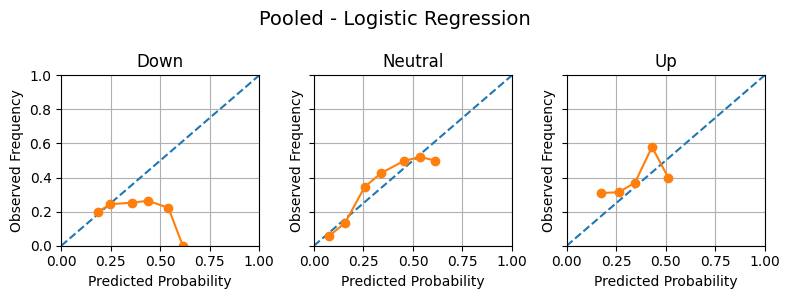

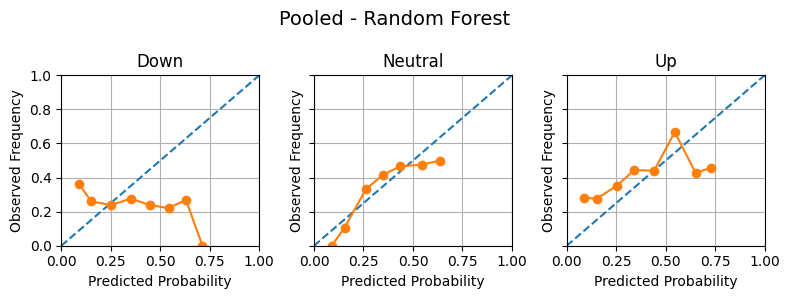

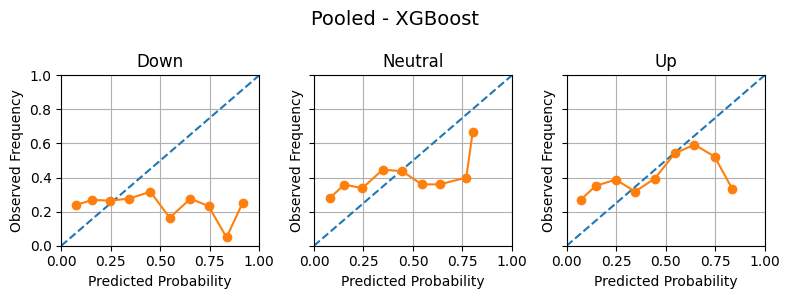

In [10]:
# ==========================================================
# Class-wise Calibration (Subplots) for "Pooled"
# ==========================================================

scenario_name = "Pooled"

scenario_df = predictions_df[
    predictions_df["scenario"] == scenario_name
]

for model, group in scenario_df.groupby("model"):

    y = group["actual"].to_numpy()
    p = group[PROB_COLS].to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)

    for ax, class_index in zip(axes, CLASS_LABELS):

        bins = classwise_bins(y, p, class_index)

        if bins.empty:
            continue

        ax.plot([0, 1], [0, 1], "--", label="Perfect")
        ax.plot(
            bins["probability"],
            bins["observed_frequency"],
            marker="o"
        )

        ax.set_title(CLASS_NAMES[class_index])
        ax.set_xlabel("Predicted Probability")
        ax.set_ylabel("Observed Frequency")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True)

    fig.suptitle(f"{scenario_name} - {model}", fontsize=14)
    plt.tight_layout()
    plt.show()

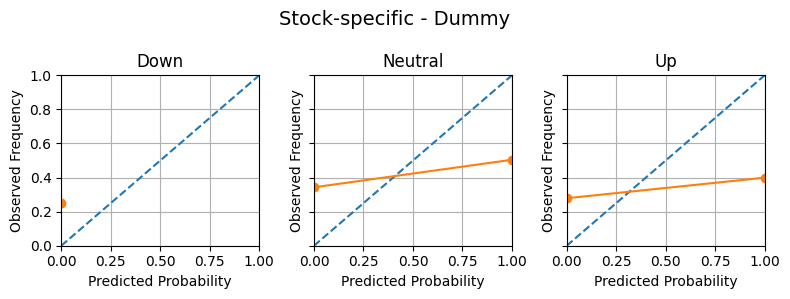

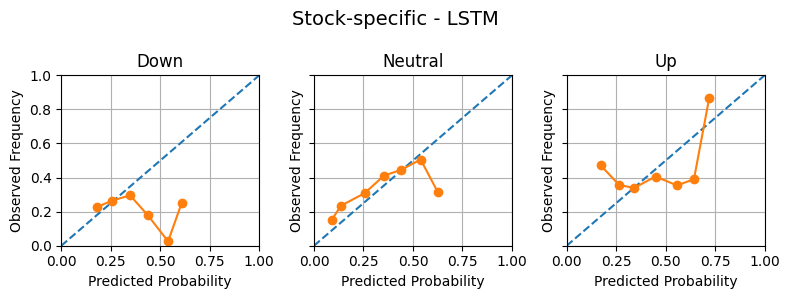

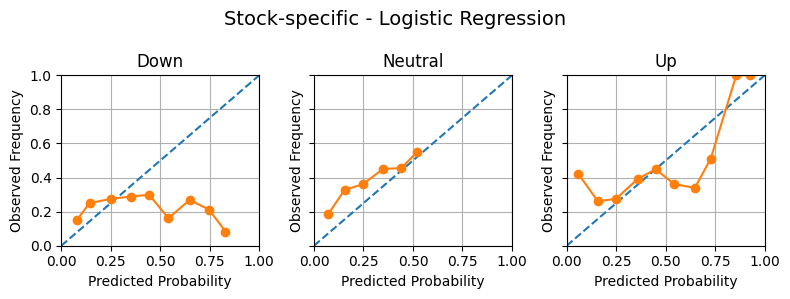

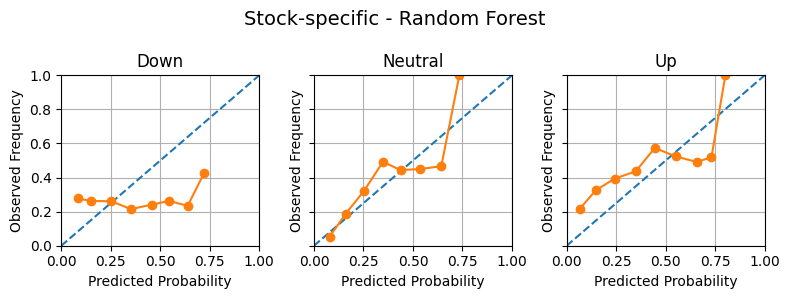

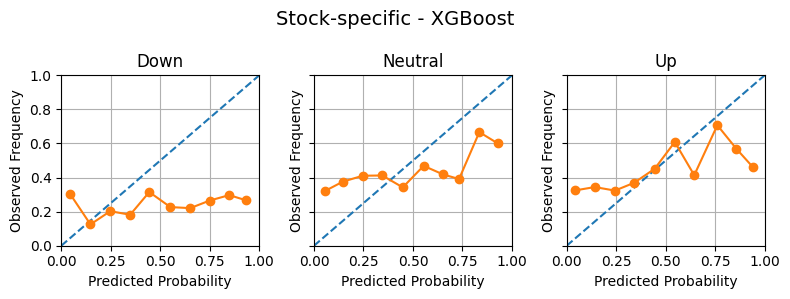

In [11]:
# ==========================================================
# Class-wise Calibration (Subplots) for "Stock-specific"
# ==========================================================

scenario_name = "Stock-specific"

scenario_df = predictions_df[
    predictions_df["scenario"] == scenario_name
]

for model, group in scenario_df.groupby("model"):

    y = group["actual"].to_numpy()
    p = group[PROB_COLS].to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)

    for ax, class_index in zip(axes, CLASS_LABELS):

        bins = classwise_bins(y, p, class_index)

        if bins.empty:
            continue

        ax.plot([0, 1], [0, 1], "--", label="Perfect")
        ax.plot(
            bins["probability"],
            bins["observed_frequency"],
            marker="o"
        )

        ax.set_title(CLASS_NAMES[class_index])
        ax.set_xlabel("Predicted Probability")
        ax.set_ylabel("Observed Frequency")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True)

    fig.suptitle(f"{scenario_name} - {model}", fontsize=14)
    plt.tight_layout()
    plt.show()

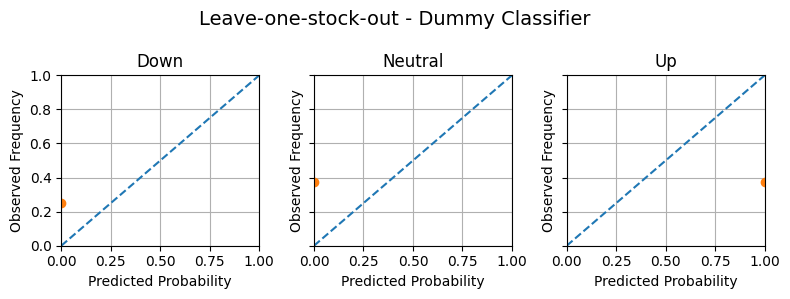

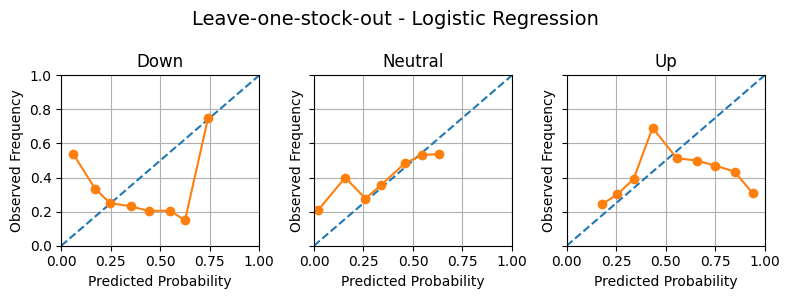

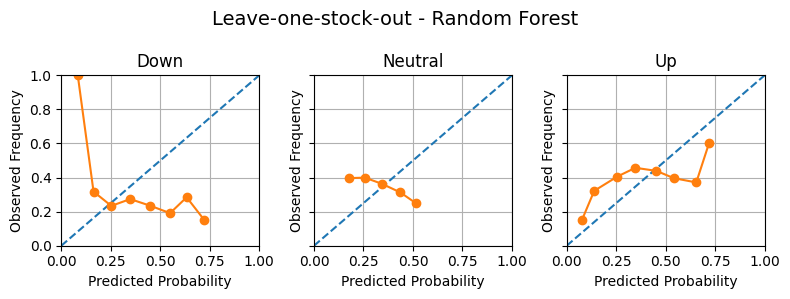

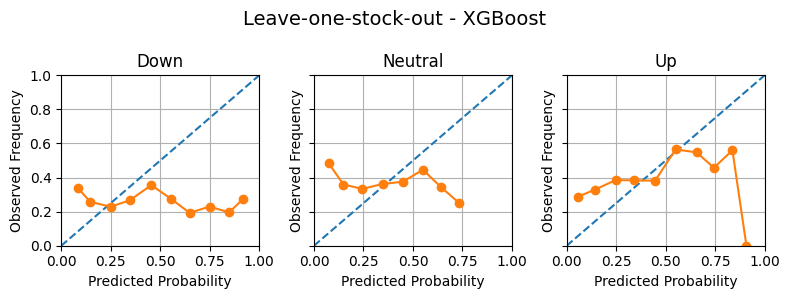

In [12]:
# ==========================================================
# Class-wise Calibration (Subplots) for "Leave-one-stock-out"
# ==========================================================

scenario_name = "Leave-one-stock-out"

scenario_df = predictions_df[
    predictions_df["scenario"] == scenario_name
]

for model, group in scenario_df.groupby("model"):

    y = group["actual"].to_numpy()
    p = group[PROB_COLS].to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)

    for ax, class_index in zip(axes, CLASS_LABELS):

        bins = classwise_bins(y, p, class_index)

        if bins.empty:
            continue

        ax.plot([0, 1], [0, 1], "--", label="Perfect")
        ax.plot(
            bins["probability"],
            bins["observed_frequency"],
            marker="o"
        )

        ax.set_title(CLASS_NAMES[class_index])
        ax.set_xlabel("Predicted Probability")
        ax.set_ylabel("Observed Frequency")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True)

    fig.suptitle(f"{scenario_name} - {model}", fontsize=14)
    plt.tight_layout()
    plt.show()

## Interpretation rules

Use the metrics together:

- **Lower Log Loss:** better probability quality.
- **Lower Brier Score:** better probabilistic accuracy, but it also reflects discrimination/resolution.
- **Lower ECE:** better agreement between confidence and empirical correctness.
- **Reliability curve closer to the diagonal:** better calibration.

Do **not** create a single combined reliability score. The measures answer related but not identical questions.

In [13]:
# ==========================================================
# Save outputs
# ==========================================================

reliability_results_df.to_csv(
    "/kaggle/working/reliability_overall_results.csv",
    index=False
)

stock_reliability_df.to_csv(
    "/kaggle/working/reliability_by_stock.csv",
    index=False
)

print("Saved:")
print("/kaggle/working/reliability_overall_results.csv")
print("/kaggle/working/reliability_by_stock.csv")

Saved:
/kaggle/working/reliability_overall_results.csv
/kaggle/working/reliability_by_stock.csv


# Conclusion

Notebook 12 answers:

> **Are the models' confidence estimates trustworthy?**

It evaluates:

- Log Loss
- Multiclass Brier Score
- Expected Calibration Error
- Maximum Calibration Error
- Reliability diagrams
- Stock-level reliability
- Class-wise calibration diagnostics

The analysis uses the predictions generated by the completed modelling experiments and keeps the 2025 test set strictly for evaluation.

The research design explicitly identifies calibration, Brier Score, Log Loss, and ECE as the reliability component.